In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [3]:
# Chuẩn hoá MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.16MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.86MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.83MB/s]

Số ảnh train: 60000,  test: 10000


In [5]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [11]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/5  train_loss=0.1855  train_acc=94.31%  test_loss=0.0613  test_acc=98.05%
Epoch 2/5  train_loss=0.0637  train_acc=98.01%  test_loss=0.0500  test_acc=98.41%
Epoch 3/5  train_loss=0.0491  train_acc=98.51%  test_loss=0.0375  test_acc=98.75%
Epoch 4/5  train_loss=0.0417  train_acc=98.72%  test_loss=0.0352  test_acc=98.71%
Epoch 5/5  train_loss=0.0361  train_acc=98.88%  test_loss=0.0340  test_acc=98.83%


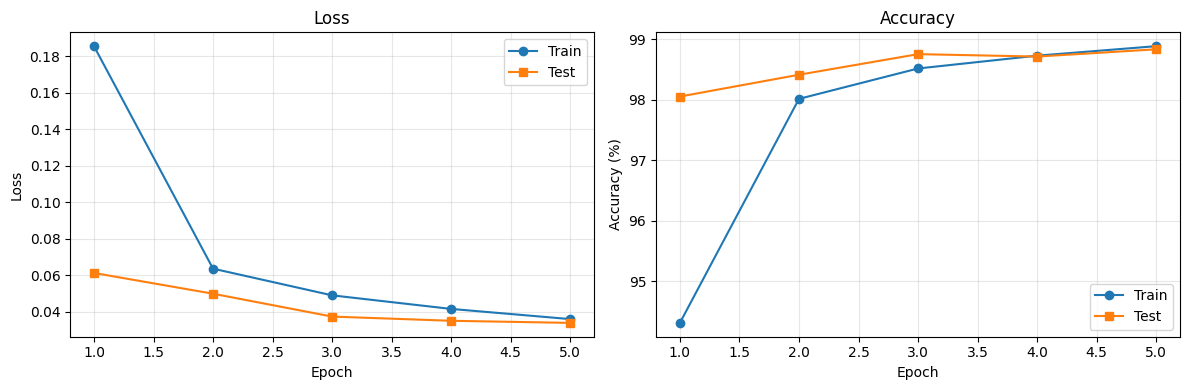

In [12]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

In [13]:
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

Final test accuracy: 98.83%
(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)


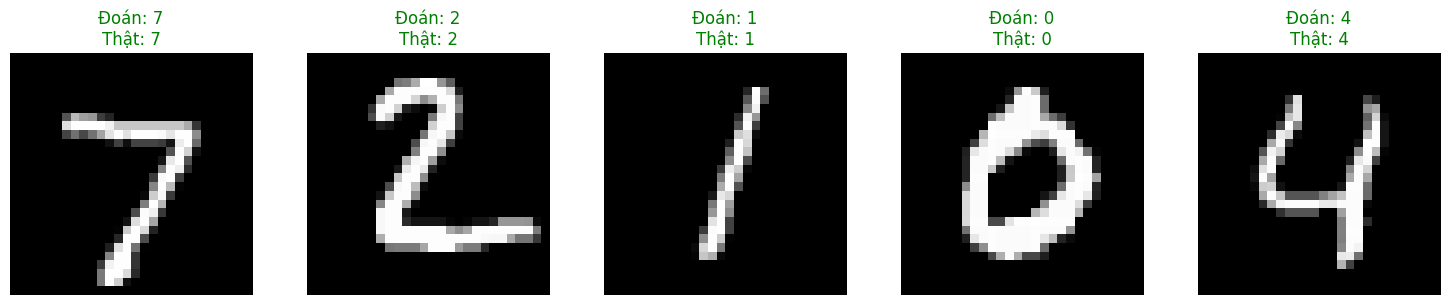

In [14]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

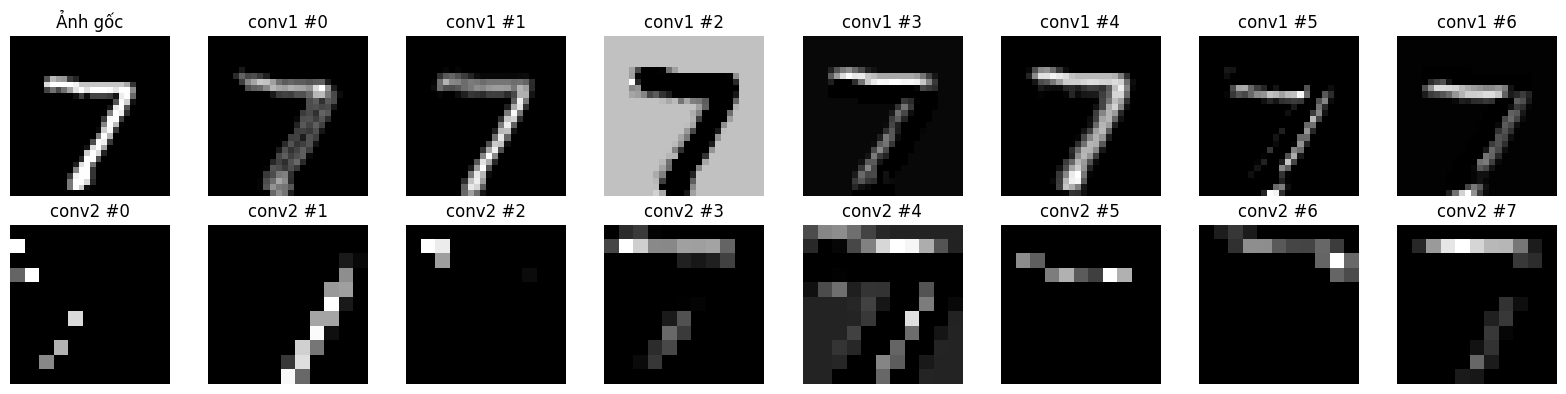

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [15]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

Cau 1

In [16]:

model_c1 = MNIST_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_c1 = optim.SGD(model_c1.parameters(), lr=0.01, momentum=0.9)

num_epochs = 10
loss_history_c1, acc_history_c1 = [], []
test_loss_history_c1, test_acc_history_c1 = [], []

for epoch in range(num_epochs):
    model_c1.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_c1.zero_grad()
        outputs = model_c1(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_c1.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model_c1, test_loader)

    loss_history_c1.append(train_loss); acc_history_c1.append(train_acc)
    test_loss_history_c1.append(test_loss); test_acc_history_c1.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs} | '
          f'Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}%')

Epoch 1/10 | Train Acc: 94.65% | Test Acc: 97.74%
Epoch 2/10 | Train Acc: 98.05% | Test Acc: 98.29%
Epoch 3/10 | Train Acc: 98.56% | Test Acc: 98.55%
Epoch 4/10 | Train Acc: 98.73% | Test Acc: 98.63%
Epoch 5/10 | Train Acc: 98.97% | Test Acc: 98.79%
Epoch 6/10 | Train Acc: 99.10% | Test Acc: 98.84%
Epoch 7/10 | Train Acc: 99.19% | Test Acc: 98.64%
Epoch 8/10 | Train Acc: 99.26% | Test Acc: 98.59%
Epoch 9/10 | Train Acc: 99.32% | Test Acc: 98.69%
Epoch 10/10 | Train Acc: 99.37% | Test Acc: 98.78%


Cau 2

In [17]:
class MNIST_CNN_3Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28 -> 26 -> pool: 13
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13 -> 11 -> pool: 5
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # 5 -> 5 -> pool: 2
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)  # flatten ra 64*2*2 = 256
        x = self.fc1(x)
        return x

model_c2 = MNIST_CNN_3Layer().to(device)
print(model_c2)

MNIST_CNN_3Layer(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=10, bias=True)
)


Cau 3

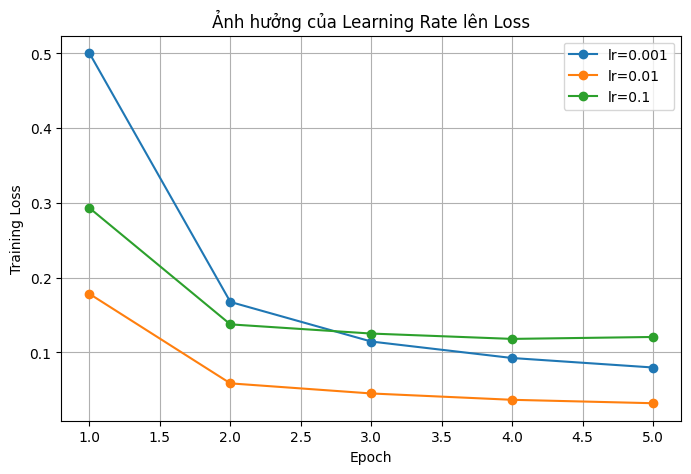

In [18]:
def train_model_lr(lr, epochs=5):
    model = MNIST_CNN().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    loss_hist = []

    for epoch in range(epochs):
        model.train()
        running_loss, total = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            total += labels.size(0)
        loss_hist.append(running_loss / total)
    return loss_hist

lrs = [0.001, 0.01, 0.1]
loss_results = {lr: train_model_lr(lr) for lr in lrs}

plt.figure(figsize=(8, 5))
for lr, loss_hist in loss_results.items():
    plt.plot(range(1, 6), loss_hist, marker='o', label=f'lr={lr}')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Ảnh hưởng của Learning Rate lên Loss')
plt.legend()
plt.grid(True)
plt.show()

Cau 4

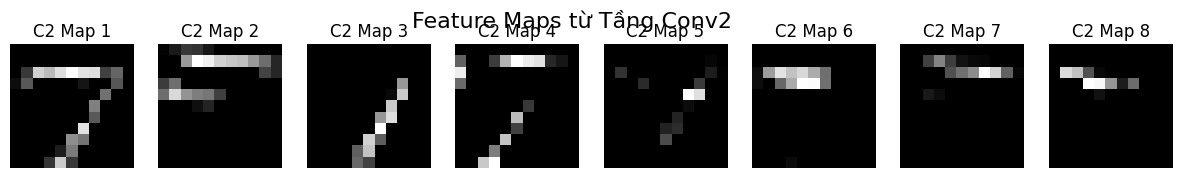

In [19]:
# Lấy 1 ảnh từ test loader
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device) # Batch size = 1

# Trích xuất feature map
model_c1.eval()
with torch.no_grad():
    h1 = torch.relu(model_c1.conv1(img))
    h1 = model_c1.pool(h1)
    h2 = torch.relu(model_c1.conv2(h1))   # h2 shape: (1, 32, 11, 11)

feature_maps_c2 = h2.squeeze(0).cpu() # Shape: (32, 11, 11)

# Trực quan hóa 8 kênh đầu tiên của conv2
fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for i in range(8):
    axes[i].imshow(feature_maps_c2[i], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'C2 Map {i+1}')
plt.suptitle('Feature Maps từ Tầng Conv2', fontsize=16)
plt.show()

Cau 5

In [20]:
# 1. Thêm augmentation vào transform (chỉ áp dụng cho train)
train_transform_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load lại data train với augmentation
train_dataset_aug = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform_aug)
train_loader_aug = torch.utils.data.DataLoader(train_dataset_aug, batch_size=64, shuffle=True)

# 2. Tạo kiến trúc mạng có Dropout
class MNIST_CNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=0)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)  # Thêm dropout trước FC
        x = self.fc1(x)
        return x

model_aug = MNIST_CNN_Dropout().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_aug = optim.SGD(model_aug.parameters(), lr=0.01, momentum=0.9)

# 3. Train model 10 epoch
for epoch in range(10):
    model_aug.train()
    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)
        optimizer_aug.zero_grad()
        loss = criterion(model_aug(images), labels)
        loss.backward()
        optimizer_aug.step()

# Đánh giá (dùng test_loader không augment đã định nghĩa đầu file)
_, test_acc_aug = evaluate(model_aug, test_loader)
print(f"Final Test Accuracy with Dropout & Augmentation: {test_acc_aug*100:.2f}%")

Final Test Accuracy with Dropout & Augmentation: 99.11%
